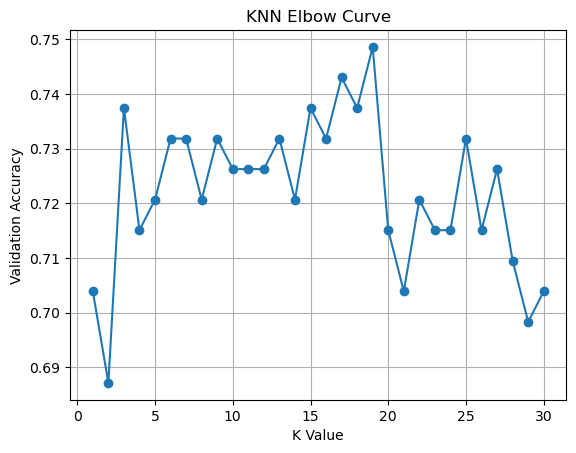

Best K: 19


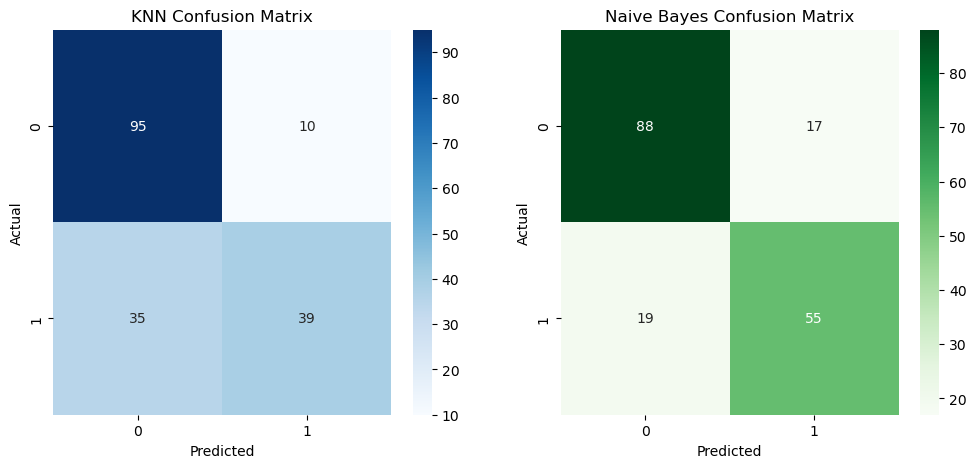


1. Features are independent of each other (conditional independence).
2. Continuous features follow Gaussian (normal) distribution.
3. All features contribute equally to the prediction.
4. Probabilities are combined using Bayes theorem.



In [2]:
# T5: KNN & Naive Bayes Comparison

# 1. Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

# 2. Load Cleaned Data

df = pd.read_csv("../data/Titanic_cleaned.csv")
X = df.drop("Survived", axis=1)
y = df["Survived"]

# 3. Train/Validation Split

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. KNN: Tune K using Elbow Method

k_values = range(1, 31)
accuracy_scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    preds = knn.predict(X_val)
    accuracy_scores.append(accuracy_score(y_val, preds))

plt.plot(k_values, accuracy_scores, marker='o')
plt.xlabel("K Value")
plt.ylabel("Validation Accuracy")
plt.title("KNN Elbow Curve")
plt.grid()
plt.show()

best_k = accuracy_scores.index(max(accuracy_scores)) + 1
print("Best K:", best_k)

# 5. Train Final KNN

knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train, y_train)
knn_preds = knn.predict(X_val)
knn_probs = knn.predict_proba(X_val)[:, 1]

# 6. Train Naive Bayes

nb = GaussianNB()
nb.fit(X_train, y_train)
nb_preds = nb.predict(X_val)
nb_probs = nb.predict_proba(X_val)[:, 1]


# 7. Metrics Function

def get_metrics(y_true, preds, probs):
    return {
        "Accuracy": accuracy_score(y_true, preds),
        "Precision": precision_score(y_true, preds),
        "Recall": recall_score(y_true, preds),
        "F1": f1_score(y_true, preds),
        "ROC-AUC": roc_auc_score(y_true, probs)
    }

knn_metrics = get_metrics(y_val, knn_preds, knn_probs)
nb_metrics = get_metrics(y_val, nb_preds, nb_probs)


# 8. Confusion Matrices

cm_knn = confusion_matrix(y_val, knn_preds)
cm_nb = confusion_matrix(y_val, nb_preds)

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.heatmap(cm_knn, annot=True, fmt="d", cmap="Blues")
plt.title("KNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.subplot(1,2,2)
sns.heatmap(cm_nb, annot=True, fmt="d", cmap="Greens")
plt.title("Naive Bayes Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


# 9. Results Table

results = pd.DataFrame({
    "KNN": knn_metrics,
    "Naive Bayes": nb_metrics
})

results


# 10. Naive Bayes Assumptions

nb_assumptions = """
1. Features are independent of each other (conditional independence).
2. Continuous features follow Gaussian (normal) distribution.
3. All features contribute equally to the prediction.
4. Probabilities are combined using Bayes theorem.
"""
print(nb_assumptions)
